# 06. Optimization and Root Finding with Numerics
his notebook covers optimization and root finding methods in Numerics.

## What You'll Learn
- Root finding (Bisection, Brent's method)
- Numerical integration
- Local optimization (Nelder-Mead, BFGS, Powell)
- Global optimization (PSO, Simulated Annealing)
- Practical applications

## When to Use Optimization vs MCMC

**Use Optimization when:**
- You need point estimates only (no uncertainty)
- Computational speed is critical
- You have a well-defined objective function

**Use MCMC when:**
- You need uncertainty quantification
- You want full posterior distributions
- You have prior information to incorporate

## Setup

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from System import Func, Double, Array
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Mathematics.Optimization import NelderMead, BFGS, Powell, ParticleSwarm, SimulatedAnnealing, AugmentedLagrange, Constraint, ConstraintType, IConstraint
from Numerics.Mathematics.RootFinding import Bisection, Brent
from Numerics.Mathematics.Integration import Integration

print("✓ Setup complete")

✓ Setup complete


## Part 1: Root Finding

**Problem:** Find x where f(x) = 0

### Methods Available:
- Bisection
- Brent
- Newton Raphson
- Secant

### Example: Quadratic Function

Find the root of f(x) = x² - 2 (true root: √2 ≈ 1.414)

We will explore the Bisection root finding method.

Bisection Method Result:
  Found root:  1.4142135605
  True root:   1.4142135624
  Error:       1.85e-09
  f(root):     -5.24e-09


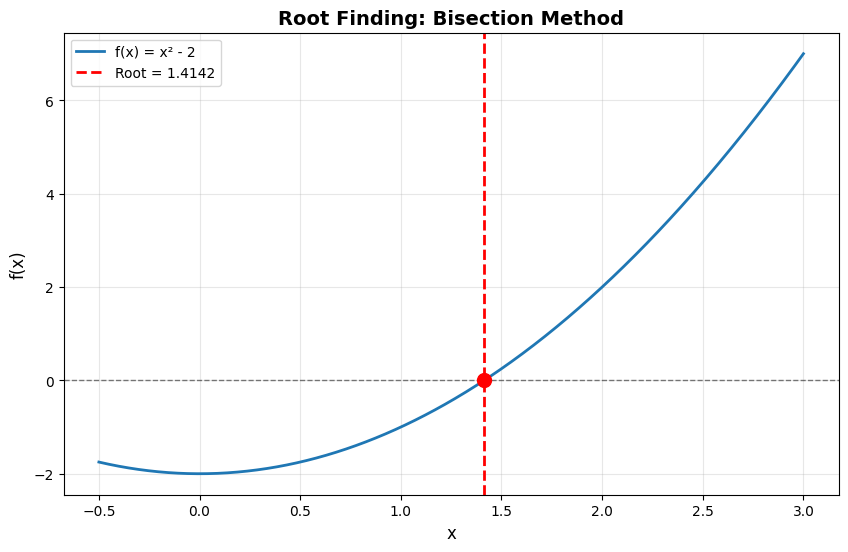

In [2]:
# Define the function
def quadratic(x):
    """f(x) = x² - 2"""
    return x * x - 2.0

# Convert to .NET Func delegate
quadratic_func = Func[Double, Double](quadratic)

# Use Bisection method
initial_guess = 1.0
lower_bound = 0.0
upper_bound = 4.0

root = Bisection.Solve(quadratic_func, initial_guess, lower_bound, upper_bound)
true_root = np.sqrt(2.0)

print(f"Bisection Method Result:")
print(f"  Found root:  {root:.10f}")
print(f"  True root:   {true_root:.10f}")
print(f"  Error:       {abs(root - true_root):.2e}")
print(f"  f(root):     {quadratic(root):.2e}")

# Visualize
x = np.linspace(-0.5, 3, 500)
y = [quadratic(xi) for xi in x]

plt.figure(figsize=(10, 6))
plt.plot(x, y, linewidth=2, label='f(x) = x² - 2')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(root, color='red', linestyle='--', linewidth=2, label=f'Root = {root:.4f}')
plt.scatter([root], [quadratic(root)], color='red', s=100, zorder=5)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Root Finding: Bisection Method', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Performance Comparison: Numerics vs SciPy

In [3]:
try:
    from scipy.optimize import root_scalar
    
    # Time Numerics
    start = time.perf_counter()
    root_numerics = Bisection.Solve(quadratic_func, initial_guess, lower_bound, upper_bound)
    time_numerics = time.perf_counter() - start
    
    # Time SciPy
    start = time.perf_counter()
    result_scipy = root_scalar(quadratic, bracket=(lower_bound, upper_bound), method='bisect')
    root_scipy = result_scipy.root
    time_scipy = time.perf_counter() - start
    
    print("\n" + "="*60)
    print("PERFORMANCE COMPARISON: Root Finding")
    print("="*60)
    print(f"Numerics Bisection:  {time_numerics*1000:.4f} ms  →  root = {root_numerics:.10f}")
    print(f"SciPy Bisection:     {time_scipy*1000:.4f} ms  →  root = {root_scipy:.10f}")
    print(f"Difference:          {abs(root_numerics - root_scipy):.2e}")
    print("="*60)
    
except ImportError:
    print("SciPy not installed. Skipping comparison.")


PERFORMANCE COMPARISON: Root Finding
Numerics Bisection:  0.7642 ms  →  root = 1.4142135605
SciPy Bisection:     0.1398 ms  →  root = 1.4142135624
Difference:          1.85e-09


### Additional Root Finding Examples

Let's try more complex functions.

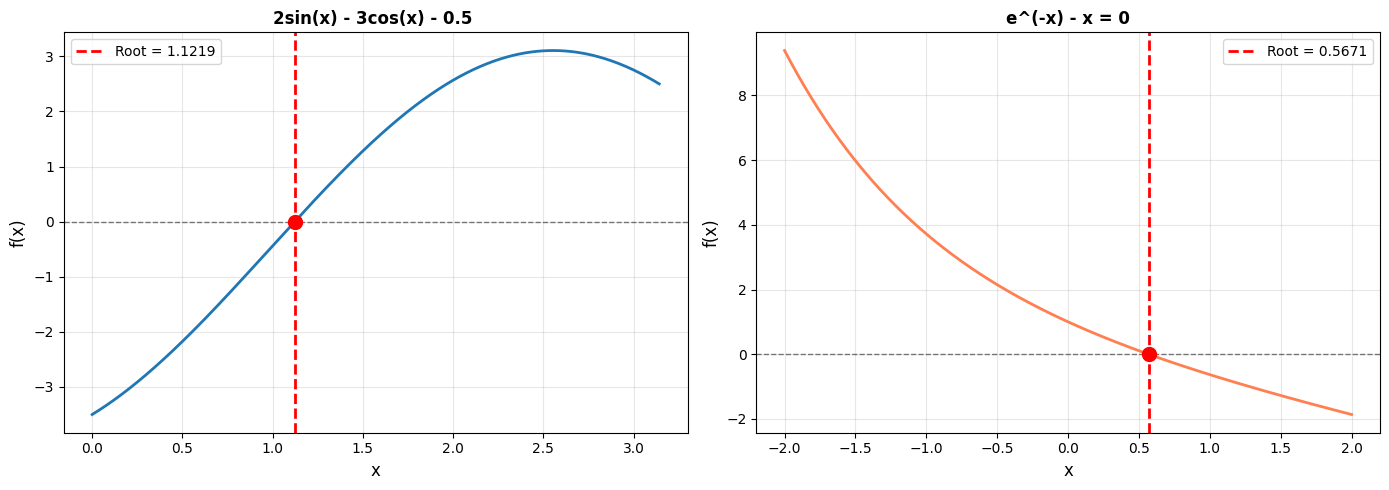


Trigonometric root:  1.121917
Exponential root:    0.567143


In [4]:
# Trigonometric function: 2sin(x) - 3cos(x) - 0.5 
def trig_func(x):
    return 2*np.sin(x) - 3*np.cos(x) - 0.5

trig_func_net = Func[Double, Double](trig_func)
root_trig = Bisection.Solve(trig_func_net, 0.5, 0.0, np.pi)

# Exponential function: e^(-x) - x 
def exp_func(x):
    return np.exp(-x) - x

exp_func_net = Func[Double, Double](exp_func)
root_exp = Bisection.Solve(exp_func_net, 1.0, -2.0, 2.0)

# Visualize both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x1 = np.linspace(0, np.pi, 500)
y1 = [trig_func(xi) for xi in x1]
ax1.plot(x1, y1, linewidth=2)
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(root_trig, color='red', linestyle='--', linewidth=2, label=f'Root = {root_trig:.4f}')
ax1.scatter([root_trig], [0], color='red', s=100, zorder=5)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('2sin(x) - 3cos(x) - 0.5 ', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

x2 = np.linspace(-2, 2, 500)
y2 = [exp_func(xi) for xi in x2]
ax2.plot(x2, y2, linewidth=2, color='coral')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.axvline(root_exp, color='red', linestyle='--', linewidth=2, label=f'Root = {root_exp:.4f}')
ax2.scatter([root_exp], [0], color='red', s=100, zorder=5)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('f(x)', fontsize=12)
ax2.set_title('e^(-x) - x = 0', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTrigonometric root:  {root_trig:.6f}")
print(f"Exponential root:    {root_exp:.6f}")

## Part 2: Numerical Integration

Compute definite integrals numerically.

### Methods Available:
- Gauss-Legendre quadrature
- Trapezoidal rule
- Simpson's rule
- Midpoint method

In [ ]:
def f_x3(x):
    return x**3

f_x3_net = Func[Double, Double](f_x3)

# Try all four methods
gauss = Integration.GaussLegendre(f_x3_net, 0, 1)
trapz = Integration.TrapezoidalRule(f_x3_net, 0, 1, 1000)
simps = Integration.SimpsonsRule(f_x3_net, 0, 1, 1000)
midpt = Integration.Midpoint(f_x3_net, 0, 1, 1000)

true_value = 0.25

print("Integration of x³ from 0 to 1:")
print("="*60)
print(f"{'Method':<20} {'Result':<15} {'Error'}")
print("="*60)
print(f"{'Gauss-Legendre':<20} {gauss:<15.10f} {abs(gauss - true_value):.2e}")
print(f"{'Trapezoidal':<20} {trapz:<15.10f} {abs(trapz - true_value):.2e}")
print(f"{'Simpson\'s Rule':<20} {simps:<15.10f} {abs(simps - true_value):.2e}")
print(f"{'Midpoint':<20} {midpt:<15.10f} {abs(midpt - true_value):.2e}")
print(f"{'True Value':<20} {true_value:<15.10f} {'---'}")
print("="*60)

### Integration Performance: Numerics vs SciPy

In [ ]:
try:
    from scipy import integrate
    
    # Time Numerics methods
    start = time.perf_counter()
    result_numerics_gauss = Integration.GaussLegendre(f_x3_net, 0, 1)
    time_numerics_gauss = time.perf_counter() - start
    
    start = time.perf_counter()
    result_numerics_simps = Integration.SimpsonsRule(f_x3_net, 0, 1, 1000)
    time_numerics_simps = time.perf_counter() - start
    
    # Time SciPy methods
    start = time.perf_counter()
    result_scipy_quad, _ = integrate.quad(f_x3, 0, 1)
    time_scipy_quad = time.perf_counter() - start
    
    x_pts = np.linspace(0, 1, 1001)
    y_pts = [f_x3(xi) for xi in x_pts]
    start = time.perf_counter()
    result_scipy_simps = integrate.simpson(y_pts, x_pts)
    time_scipy_simps = time.perf_counter() - start
    
    print("\n" + "="*70)
    print("PERFORMANCE COMPARISON: Integration")
    print("="*70)
    print(f"{'Method':<30} {'Time (ms)':<12} {'Result':<15}")
    print("="*70)
    print(f"{'Numerics Gauss-Legendre':<30} {time_numerics_gauss*1000:<12.4f} {result_numerics_gauss:<15.10f}")
    print(f"{'SciPy quad':<30} {time_scipy_quad*1000:<12.4f} {result_scipy_quad:<15.10f}")
    print(f"{'Numerics Simpson':<30} {time_numerics_simps*1000:<12.4f} {result_numerics_simps:<15.10f}")
    print(f"{'SciPy Simpson':<30} {time_scipy_simps*1000:<12.4f} {result_scipy_simps:<15.10f}")
    print("="*70)
    
except ImportError:
    print("SciPy not installed. Skipping comparison.")

## Part 3: Local Optimization

Find minimum or maximum of a function.

### Methods Available:
- Adam
- BFGS
- Brent Search
- Golden Selection
- Gradient Descent
- Nelder Mead
- Powell


### Example: Rosenbrock Function

The Rosenbrock function is a classic optimization test problem:
f(x, y) = (a - x)² + b(y - x²)²

With a=1, b=100, the global minimum is at (1, 1) with f(1,1) = 0

We will use this function to explore BFGS, Nelder Mead, and Powell methods.

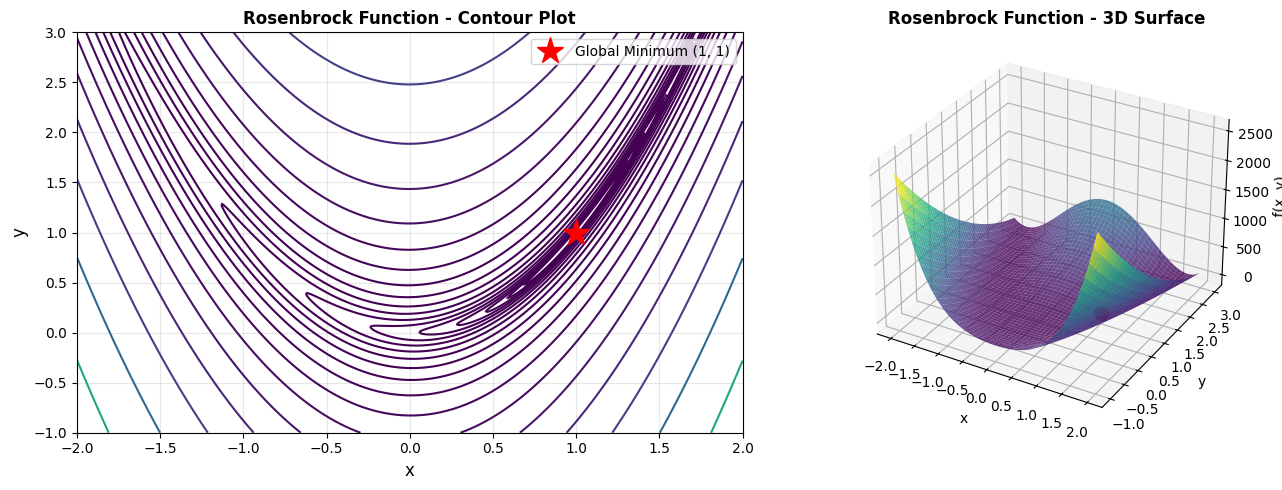

Global minimum:
  Location: (1, 1)
  Value:    0

 Finding Minimum of Rosenbrock Function:
     Method                               Result                 Error
       BFGS           [0.999999944, 0.999999888] [-5.6e-08, -1.12e-07]
Nelder-Mead           [0.999999998, 0.999999995]      [-2e-09, -5e-09]
     Powell [0.99999999999999, 0.99999999999998]      [-1e-14, -2e-14]


In [5]:
# Rosenbrock function
def rosenbrock(params):
    n = len(params)
    F = 0
    for i in range(n-1):
        F += 100 * (params[i + 1] - params[i] * params[i])**2 + (1 - params[i])**2
    return F

# Visualize the function
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(14, 5))

# Contour plot
ax1 = fig.add_subplot(121)
contour = ax1.contour(X, Y, Z, levels=np.logspace(-1, 3.5, 20), cmap='viridis')
ax1.plot(1, 1, 'r*', markersize=20, label='Global Minimum (1, 1)')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Rosenbrock Function - Contour Plot', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3D surface
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax2.scatter([1], [1], [0], color='red', s=100, label='Minimum')
ax2.set_xlabel('x', fontsize=10)
ax2.set_ylabel('y', fontsize=10)
ax2.set_zlabel('f(x, y)', fontsize=10)
ax2.set_title('Rosenbrock Function - 3D Surface', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Global minimum:")
print(f"  Location: (1, 1)")
print(f"  Value:    {rosenbrock([1, 1])}")

initial = Array[Double]([0.0, 0.0])
lower = Array[Double]([-2.048, -2.048])
upper = Array[Double]([2.048, 2.048])

rosenbrock_net = Func[Array[Double], Double](rosenbrock)

bfgs = BFGS(rosenbrock_net, 2, initial, lower, upper)
bfgs.Minimize()
bfgs_soln = bfgs.BestParameterSet.Values

nelder = NelderMead(rosenbrock_net, 2, initial, lower, upper)
nelder.Minimize()
nelder_soln = nelder.BestParameterSet.Values

powell = Powell(rosenbrock_net, 2, initial, lower, upper)
powell.Minimize()
powell_soln = powell.BestParameterSet.Values

print('\n'  + " Finding Minimum of Rosenbrock Function:")
print("="*60)

table = pd.DataFrame([
    {'Method': 'BFGS',
                'Result': np.round(bfgs_soln, 9),
                'Error': np.round(list(bfgs_soln) - np.array([1, 1]), 9)},
        {'Method': 'Nelder-Mead',
                'Result': np.round(nelder_soln,9),
                'Error': np.round(list(nelder_soln) - np.array([1, 1]), 9)},
        {'Method': 'Powell',
                'Result': np.round(powell_soln, 14),
                'Error': np.round(list(powell_soln) - np.array([1, 1]), 14)}])

print(table.to_string(index=False))


## Part 4: Global Optimization
Find minimum or maximum of a function.

### Methods Available:
- Differential Evolution
- MLSL
- Multi Start
- Particle Swarm
- Shuffled Complex Evolution
- Simulated Annealing

We will continue with the Rosenbrock function, now in 5D, to explore Particle Swarm and Simulated Annealing.

In [6]:
lower = Array[Double]([-2.048, -2.048, -2.048, -2.048, -2.048])
upper = Array[Double]([2.048, 2.048, 2.048, 2.048, 2.048])

particle = ParticleSwarm(rosenbrock_net, 5, lower, upper)
particle.PopulationSize = 100
particle.MaxIterations = 100000
particle.Minimize()
particle_soln = particle.BestParameterSet.Values

anneling = SimulatedAnnealing(rosenbrock_net, 5, lower, upper)
anneling.Minimize()
anneling_soln = anneling.BestParameterSet.Values

print('\n'  + " Finding Minimum of Rosenbrock Function:")
print("="*60)

table = pd.DataFrame([
    {'Method': 'Particle Swarm',
                'Result': np.round(particle_soln, 14),
                'Error': np.round(list(particle_soln) - np.array([1, 1, 1, 1, 1]), 14)},
        {'Method': 'Simulated Annealing',
                'Result': np.round(anneling_soln, 4),
                'Error': np.round(list(anneling_soln) - np.array([1, 1, 1, 1, 1]), 4)}
                ])
print(table.to_string(index=False))


 Finding Minimum of Rosenbrock Function:
             Method                                                                                     Result                                    Error
     Particle Swarm [0.99999999999999, 0.99999999999999, 0.99999999999998, 0.99999999999996, 0.99999999999991] [-1e-14, -1e-14, -2e-14, -4e-14, -9e-14]
Simulated Annealing                                                     [1.0001, 1.0002, 1.0005, 1.001, 1.002]   [0.0001, 0.0002, 0.0005, 0.001, 0.002]


## Part 5: Constrained Optimization (Augmented Lagrange)

We will now use the Rosenbrock function constrained to a disk to tes the Augmented Lagrange Algorithm.

In [7]:
def constraint(x):
    return x[0]*x[0] + x[1]*x[1]

def rosenbrock_disk(params):
    return np.power(1 - params[0], 2) + 100*(np.power(params[1] - params[0]*params[0], 2))

rosenbrock_disk_net = Func[Array[Double], Double](rosenbrock_disk)
constraint_net = Func[Array[Double], Double](constraint)

# Set up inner solver
initial = Array[Double]([0.0, 0.0])
lower = Array[Double]([-1.5, -1.5])
upper = Array[Double]([1.5, 1.5])
inner_solver = BFGS(rosenbrock_disk_net, 2, initial, lower, upper)

# Set up constraint
constraint = Constraint(constraint_net, 2, 2, ConstraintType.LesserThanOrEqualTo)

# Solve
constraint_list = List[IConstraint]()
constraint_list.Add(constraint)

solver = AugmentedLagrange(rosenbrock_disk_net, inner_solver, constraint_list)
solver.Minimize()
soln = solver.BestParameterSet.Values

# Results
print('\n'  + " Finding Minimum of Rosenbrock Function Constrained to a Disk:")
print("="*60)

table = pd.DataFrame([
    {'Method': 'Augmented Lagrange',
                'Result': np.round(soln, 6),
                'Error': np.round(list(soln) - np.array([1, 1]), 6)},
])
print(table.to_string(index=False))



 Finding Minimum of Rosenbrock Function Constrained to a Disk:
            Method               Result            Error
Augmented Lagrange [0.999998, 0.999996] [-2e-06, -4e-06]


## Summary: When to Use Each Method

### Root Finding
- **Bisection:** Simple, robust, guaranteed convergence (if root is bracketed)
- **Brent:** Faster than Bisection, combines bisection with inverse quadratic interpolation

### Integration
- **Gauss-Legendre:** Best for smooth functions, adaptive
- **Simpson's Rule:** Good balance of accuracy and speed
- **Trapezoidal:** Simplest, use for rough estimates
- **Midpoint:** Alternative to trapezoidal

### Local Optimization
- **Powell:** Direction-set method, derivative free, good when gradients are unreliable or discountinuous
- **Nelder-Mead:** Derivative-free, good for noisy functions
- **BFGS:** Fast, requires smooth functions and resonably cheap gradient evaluations

### Global Optimization
- **Particle Swarm:** Global optimization, handles multimodal functions, easy to tune
- **Simulated Annealing:** Global optimization via stochastic hill-clibing, good for escaping local minima but can be slow to converge

## Constrained Optimization
- **Augmented Lagrange:** Handles constraints by adding penalty and Lagrange multiplier terms to the objective, useful when converting constrained problems into a sequece of unconstrained problems

### MCMC (from notebooks 03-04)
- **Use when:** Need uncertainty quantification, have prior knowledge, want full posterior
- **Don't use when:** Only need point estimates and speed matters


## Practical Tips: Choosing Initial Points, Handling Bounds, etc